# 🔍 Similaridade entre Produtos
**Instacart Market Basket Analysis · Etapa 4**

Cálculo de similaridade **produto a produto** usando a matriz usuário-item esparsa e similaridade cosseno, complementando o Market Basket (que captura coocorrência) com uma visão baseada em **padrão de consumo agregado**.

**Abordagem:**
1. Construir matriz esparsa usuário × produto (a partir do histórico `prior`)
2. Calcular similaridade cosseno entre vetores de produto (colunas da matriz)
3. Validar com exemplos e visualizações (incluindo redução de dimensionalidade)
4. Avaliar a qualidade com métricas de ranking

---

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import TruncatedSVD

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", palette="viridis")

## 📂 1. Carregamento dos Dados

In [2]:
DATA_PATH      = Path("../data/raw")
PROCESSED_PATH = Path("../data/processed")

order_products_prior = pd.read_csv(DATA_PATH / "order_products__prior.csv")
orders   = pd.read_csv(DATA_PATH / "orders.csv")
products = pd.read_parquet(PROCESSED_PATH / "products_enriched.parquet")

product_name_map = dict(zip(products["product_id"], products["product_name"]))

print(f"order_products_prior: {order_products_prior.shape}")
print(f"orders:               {orders.shape}")
print(f"products:             {products.shape}")

order_products_prior: (32434489, 4)
orders:               (3421083, 7)
products:             (49688, 6)


## 🧱 2. Construção da Matriz Esparsa Usuário × Produto

In [3]:
# ── Filtra produtos com suporte mínimo (reduz ruído e dimensionalidade) ──
MIN_PRODUCT_PURCHASES = 50

product_counts = order_products_prior["product_id"].value_counts()
valid_products = product_counts[product_counts >= MIN_PRODUCT_PURCHASES].index

filtered = order_products_prior[
    order_products_prior["product_id"].isin(valid_products)
].merge(orders[["order_id","user_id"]], on="order_id")

print(f"📦 Produtos válidos (>= {MIN_PRODUCT_PURCHASES} compras): {len(valid_products):,}")
print(f"📊 Interações após filtro: {len(filtered):,}")

📦 Produtos válidos (>= 50 compras): 26,686
📊 Interações após filtro: 32,002,318


In [4]:
# ── Codifica user_id e product_id como índices contíguos ──
user_ids    = filtered["user_id"].unique()
product_ids = filtered["product_id"].unique()

user_to_idx    = {uid: i for i, uid in enumerate(user_ids)}
product_to_idx = {pid: i for i, pid in enumerate(product_ids)}
idx_to_product = {i: pid for pid, i in product_to_idx.items()}

rows = filtered["user_id"].map(user_to_idx).values
cols = filtered["product_id"].map(product_to_idx).values
data = np.ones(len(filtered), dtype=np.float32)

user_item_matrix = csr_matrix(
    (data, (rows, cols)),
    shape=(len(user_ids), len(product_ids))
)

sparsity = 1 - user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1])
print(f"🧱 Matriz: {user_item_matrix.shape[0]:,} usuários × {user_item_matrix.shape[1]:,} produtos")
print(f"🧱 Esparsidade: {sparsity:.4%}")
print(f"🧱 Memória: {user_item_matrix.data.nbytes / 1e6:.1f} MB")

🧱 Matriz: 206,206 usuários × 26,686 produtos
🧱 Esparsidade: 99.7636%
🧱 Memória: 52.0 MB


## 📐 3. Similaridade Cosseno entre Produtos

In [5]:
# Similaridade cosseno entre colunas (produtos) — usa a transposta
item_item_similarity = cosine_similarity(user_item_matrix.T, dense_output=False)

print(f"✅ Matriz de similaridade: {item_item_similarity.shape}")
print(f"   Esparsidade: {1 - item_item_similarity.nnz/(item_item_similarity.shape[0]**2):.4%}")

✅ Matriz de similaridade: (26686, 26686)
   Esparsidade: 74.1016%


## 🔍 4. Função de Busca por Similaridade

In [6]:
def find_product_id(query: str) -> int | None:
    """Busca product_id por nome exato ou parcial."""
    q = query.lower().strip()
    exact = products[products["product_name"].str.lower().str.strip() == q]
    if not exact.empty:
        return exact.iloc[0]["product_id"]
    partial = products[products["product_name"].str.lower().str.contains(q, regex=False)]
    if not partial.empty:
        return partial.iloc[0]["product_id"]
    return None


def get_similar_products(product_name: str, top_n: int = 10) -> pd.DataFrame:
    """Retorna os produtos mais similares (cosseno) a um produto de entrada."""
    pid = find_product_id(product_name)
    if pid is None or pid not in product_to_idx:
        print(f"❌ Produto '{product_name}' não encontrado na matriz filtrada.")
        return pd.DataFrame()

    idx = product_to_idx[pid]
    sims = item_item_similarity[idx].toarray().flatten()
    sims[idx] = -1  # exclui o próprio produto

    top_idx = np.argpartition(-sims, top_n)[:top_n]
    top_idx = top_idx[np.argsort(-sims[top_idx])]

    result = pd.DataFrame({
        "product_id": [idx_to_product[i] for i in top_idx],
        "similarity": sims[top_idx],
    })
    result["product_name"] = result["product_id"].map(product_name_map)

    matched_name = product_name_map.get(pid, product_name)
    print(f"🔍 Produtos similares a: {matched_name}")
    return result[["product_name","similarity","product_id"]].reset_index(drop=True)

## 🧪 5. Testes da Similaridade

In [7]:
get_similar_products("Organic Strawberries", top_n=10)

🔍 Produtos similares a: Organic Strawberries


,product_name,similarity,product_id
0,Organic Hass Avocado,0.474432,47209
1,Bag of Organic Bananas,0.468621,13176
2,Organic Raspberries,0.464203,27966
3,Organic Blueberries,0.425009,39275
4,Organic Baby Spinach,0.413461,21903
5,Apple Honeycrisp Organic,0.392543,8277
6,Organic Yellow Onion,0.369042,22935
7,Organic Grape Tomatoes,0.355040,40706
8,Banana,0.350425,24852
9,Organic Garlic,0.344336,24964


In [8]:
get_similar_products("Organic Whole Milk", top_n=10)

🔍 Produtos similares a: Organic Whole Milk


,product_name,similarity,product_id
0,Organic Strawberries,0.309395,21137
1,Banana,0.246408,24852
2,Bag of Organic Bananas,0.234149,13176
3,Organic Whole String Cheese,0.230119,22035
4,Organic Baby Spinach,0.225425,21903
5,Organic Hass Avocado,0.209376,47209
6,Organic Garlic,0.206475,24964
7,Whole Milk Plain Yogurt,0.206176,6104
8,Grated Parmesan,0.202345,33731
9,Organic Avocado,0.197491,47766


In [9]:
get_similar_products("Banana", top_n=10)

🔍 Produtos similares a: Banana


,product_name,similarity,product_id
0,Organic Avocado,0.360694,47766
1,Large Lemon,0.358767,47626
2,Organic Strawberries,0.350425,21137
3,Organic Fuji Apple,0.346534,28204
4,Strawberries,0.343159,16797
5,Cucumber Kirby,0.324425,49683
6,Organic Baby Spinach,0.322512,21903
7,Yellow Onions,0.314615,4605
8,Limes,0.313416,26209
9,Honeycrisp Apple,0.312094,45066


## 📊 6. Visualizações

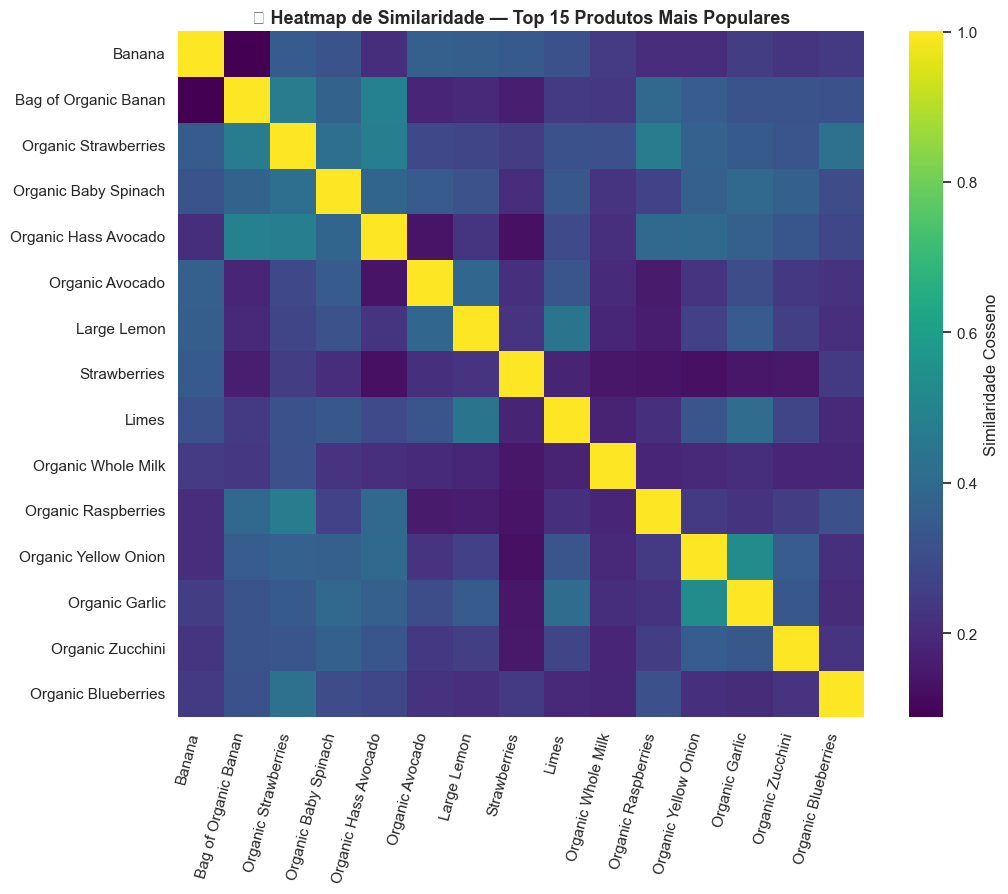

In [10]:
# ── Heatmap de similaridade entre os 15 produtos mais populares ──
top15_pids = product_counts.head(15).index.tolist()
top15_pids = [p for p in top15_pids if p in product_to_idx]
top15_idx  = [product_to_idx[p] for p in top15_pids]
top15_names = [product_name_map[p][:20] for p in top15_pids]

sub_sim = item_item_similarity[np.ix_(top15_idx, top15_idx)].toarray()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(sub_sim, xticklabels=top15_names, yticklabels=top15_names,
            cmap="viridis", annot=False, square=True, cbar_kws={"label":"Similaridade Cosseno"})
ax.set_title("🔥 Heatmap de Similaridade — Top 15 Produtos Mais Populares", fontsize=13, fontweight="bold")
plt.xticks(rotation=75, ha="right")
plt.tight_layout()
plt.show()

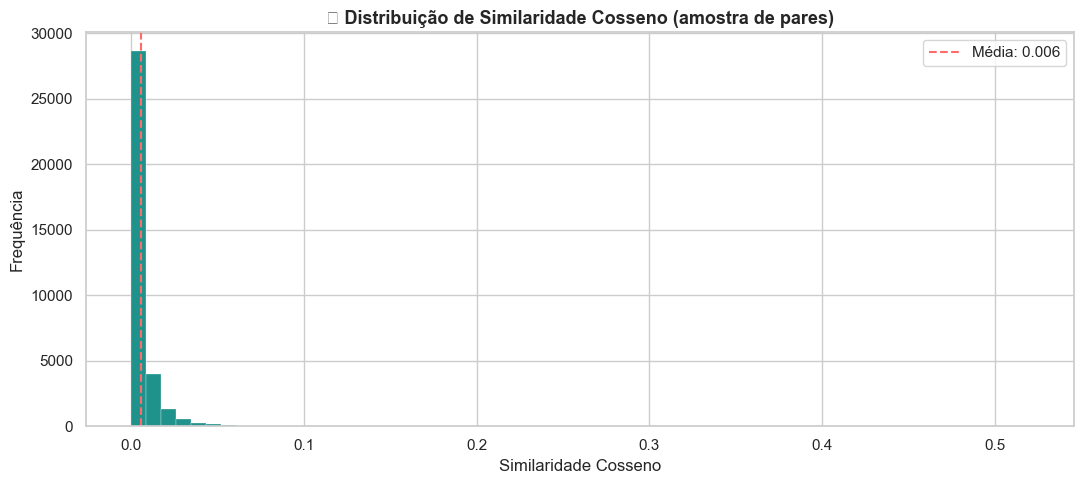

In [11]:
# ── Distribuição geral de similaridade (amostra) ──
sample_idx = np.random.choice(item_item_similarity.shape[0], size=min(500, item_item_similarity.shape[0]), replace=False)
sample_sim = item_item_similarity[sample_idx][:, sample_idx].toarray()
sim_values = sample_sim[np.triu_indices_from(sample_sim, k=1)]
sim_values = sim_values[sim_values > 0]

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(sim_values, bins=60, color=sns.color_palette("viridis", 60)[30], edgecolor="white", lw=0.2)
ax.set_title("📊 Distribuição de Similaridade Cosseno (amostra de pares)", fontsize=13, fontweight="bold")
ax.set_xlabel("Similaridade Cosseno"); ax.set_ylabel("Frequência")
ax.axvline(sim_values.mean(), color="#ff6b6b", linestyle="--", label=f"Média: {sim_values.mean():.3f}")
ax.legend()
plt.tight_layout()
plt.show()

## 🗺️ 7. Visualização 2D dos Produtos (TruncatedSVD)

Reduzimos a matriz usuário-item a 2 dimensões para visualizar como os produtos se agrupam no espaço latente — uma prévia conceitual do que faremos de forma mais sofisticada no notebook de **Embeddings**.

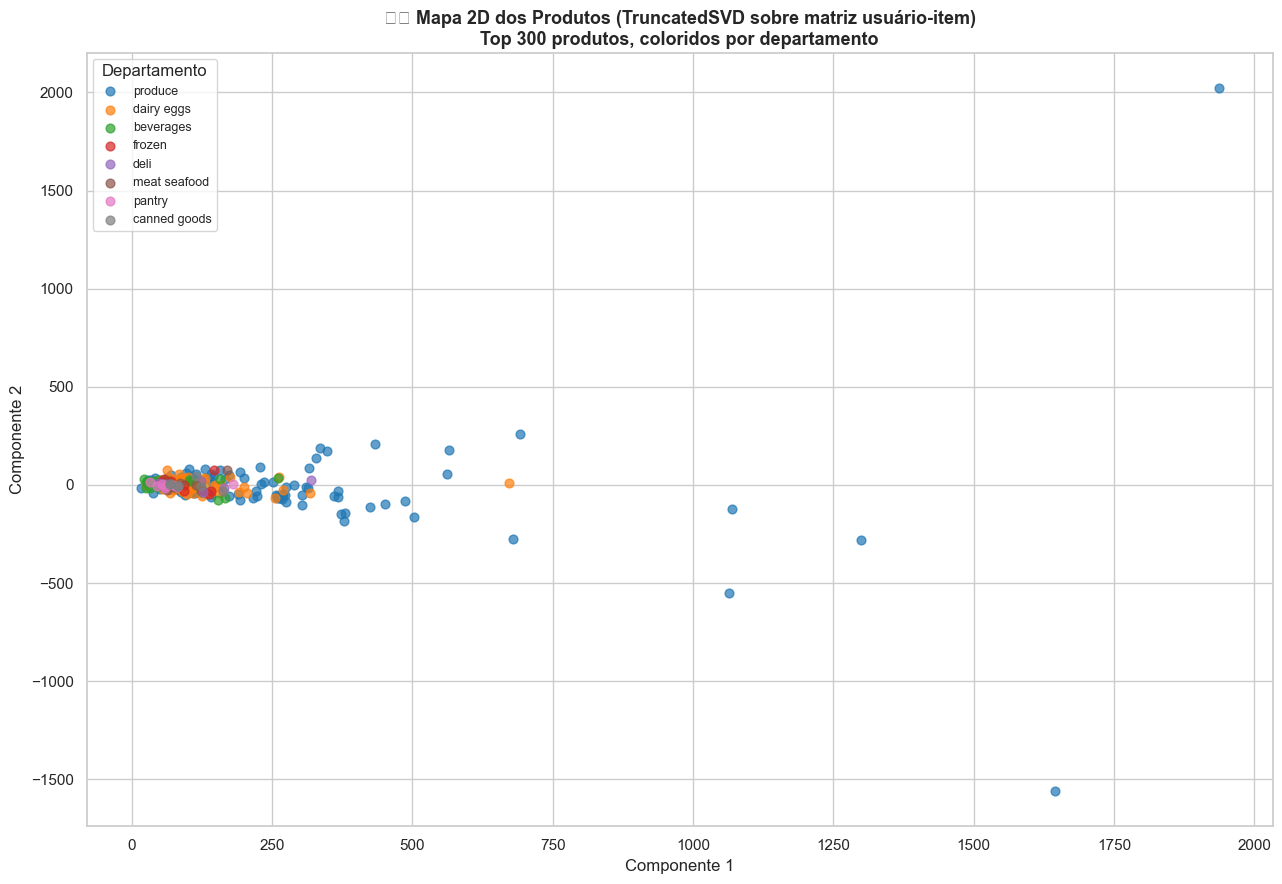

📊 Variância explicada (2 componentes): 18.78%


In [12]:
N_VIZ_PRODUCTS = 300
top_products_for_viz = product_counts.head(N_VIZ_PRODUCTS).index
viz_idx = [product_to_idx[p] for p in top_products_for_viz if p in product_to_idx]

svd = TruncatedSVD(n_components=2, random_state=42)
coords_2d = svd.fit_transform(user_item_matrix.T.tocsr()[viz_idx])

viz_df = pd.DataFrame({
    "x": coords_2d[:, 0],
    "y": coords_2d[:, 1],
    "product_id": [idx_to_product[i] for i in viz_idx],
})
viz_df = viz_df.merge(products[["product_id","product_name","department"]], on="product_id")

fig, ax = plt.subplots(figsize=(13, 9))
departments_top = viz_df["department"].value_counts().head(8).index
palette = dict(zip(departments_top, sns.color_palette("tab10", len(departments_top))))

for dept in departments_top:
    sub = viz_df[viz_df["department"] == dept]
    ax.scatter(sub["x"], sub["y"], label=dept, alpha=0.7, s=40, color=palette[dept])

ax.set_title("🗺️ Mapa 2D dos Produtos (TruncatedSVD sobre matriz usuário-item)\nTop 300 produtos, coloridos por departamento",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Componente 1"); ax.set_ylabel("Componente 2")
ax.legend(loc="best", fontsize=9, title="Departamento")
plt.tight_layout()
plt.show()

print(f"📊 Variância explicada (2 componentes): {svd.explained_variance_ratio_.sum():.2%}")

## 📐 8. Avaliação — Recall@K usando Similaridade como Recomendador

In [15]:
import gc
import numpy as np
import pandas as pd

def evaluate_similarity_recommender(eval_df, K_values=(5, 10, 20)):
    """Avalia o recomendador de similaridade cosseno como produto → produto."""
    results = {}

    for K in K_values:
        precisions, recalls = [], []

        for _, row in eval_df.iterrows():
            input_pid = row["input_product_id"]
            true_pids = row["true_product_ids"]

            if input_pid not in product_to_idx:
                continue

            idx = product_to_idx[input_pid]

            sims = item_item_similarity[idx].toarray().ravel()
            sims[idx] = -1

            k = min(K, len(sims) - 1)

            top_idx = np.argpartition(-sims, k - 1)[:k]
            top_idx = top_idx[np.argsort(-sims[top_idx])]

            recommended = {idx_to_product[i] for i in top_idx}
            hits = len(recommended & true_pids)

            precisions.append(hits / k)
            recalls.append(hits / len(true_pids) if len(true_pids) > 0 else 0)

        results[K] = {
            "Precision@K": round(np.mean(precisions), 4) if precisions else 0,
            "Recall@K": round(np.mean(recalls), 4) if recalls else 0,
            "n_eval": len(precisions),
        }

    return pd.DataFrame(results).T.rename_axis("K")


# ============================================================
# 1. Reduz memória antes de começar
# ============================================================

gc.collect()

# Se order_products_prior estiver carregado inteiro, libere memória
try:
    del order_products_prior
    gc.collect()
except NameError:
    pass


# ============================================================
# 2. Prepara orders com tipos menores
# ============================================================

orders_small = orders[["user_id", "order_id", "eval_set", "order_number"]].copy()

orders_small["user_id"] = orders_small["user_id"].astype("int32")
orders_small["order_id"] = orders_small["order_id"].astype("int32")
orders_small["order_number"] = orders_small["order_number"].astype("int16")


# ============================================================
# 3. Descobre o último pedido prior de cada usuário
# ============================================================

prior_orders = orders_small.loc[
    orders_small["eval_set"] == "prior",
    ["user_id", "order_id", "order_number"]
]

idx_last_prior = prior_orders.groupby("user_id")["order_number"].idxmax()

last_prior_orders = prior_orders.loc[
    idx_last_prior,
    ["user_id", "order_id"]
].rename(columns={"order_id": "last_prior_order_id"})

last_prior_order_ids = set(last_prior_orders["last_prior_order_id"].astype("int32"))


# ============================================================
# 4. Lê order_products__prior.csv em pedaços
#    para pegar apenas os produtos dos últimos pedidos prior
# ============================================================

prior_chunks = []

for chunk in pd.read_csv(
    DATA_PATH / "order_products__prior.csv",
    usecols=["order_id", "product_id", "add_to_cart_order"],
    dtype={
        "order_id": "int32",
        "product_id": "int32",
        "add_to_cart_order": "int16"
    },
    chunksize=1_000_000
):
    chunk = chunk[chunk["order_id"].isin(last_prior_order_ids)]

    if not chunk.empty:
        prior_chunks.append(chunk)

last_prior_products = pd.concat(prior_chunks, ignore_index=True)

del prior_chunks
gc.collect()


# ============================================================
# 5. Pega o último produto adicionado no último pedido prior
# ============================================================

idx_last_product = last_prior_products.groupby("order_id")["add_to_cart_order"].idxmax()

last_prior_product = last_prior_products.loc[
    idx_last_product,
    ["order_id", "product_id"]
].rename(columns={
    "order_id": "last_prior_order_id",
    "product_id": "input_product_id"
})

last_prior = last_prior_orders.merge(
    last_prior_product,
    on="last_prior_order_id",
    how="inner"
)[["user_id", "input_product_id"]]

del last_prior_products, last_prior_product, prior_orders, last_prior_orders
gc.collect()


# ============================================================
# 6. Monta ground truth com pedidos train
# ============================================================

train_orders = orders_small.loc[
    orders_small["eval_set"] == "train",
    ["user_id", "order_id"]
]

order_products_train = pd.read_csv(
    DATA_PATH / "order_products__train.csv",
    usecols=["order_id", "product_id"],
    dtype={
        "order_id": "int32",
        "product_id": "int32"
    }
)

train_products = order_products_train.merge(
    train_orders,
    on="order_id",
    how="inner"
)

train_sets = (
    train_products
    .groupby("user_id")["product_id"]
    .apply(set)
    .reset_index()
    .rename(columns={"product_id": "true_product_ids"})
)

del order_products_train, train_orders, train_products
gc.collect()


# ============================================================
# 7. Avaliação
# ============================================================

eval_df = last_prior.merge(train_sets, on="user_id", how="inner")

eval_sample = eval_df.sample(
    min(2000, len(eval_df)),
    random_state=42
)

metrics = evaluate_similarity_recommender(
    eval_sample,
    K_values=[5, 10, 20]
)

print("📊 Métricas — Similaridade Cosseno como Recomendador")
print(metrics.to_string())

📊 Métricas — Similaridade Cosseno como Recomendador
    Precision@K  Recall@K  n_eval
K                                
5        0.0363    0.0192  1968.0
10       0.0312    0.0318  1968.0
20       0.0259    0.0515  1968.0


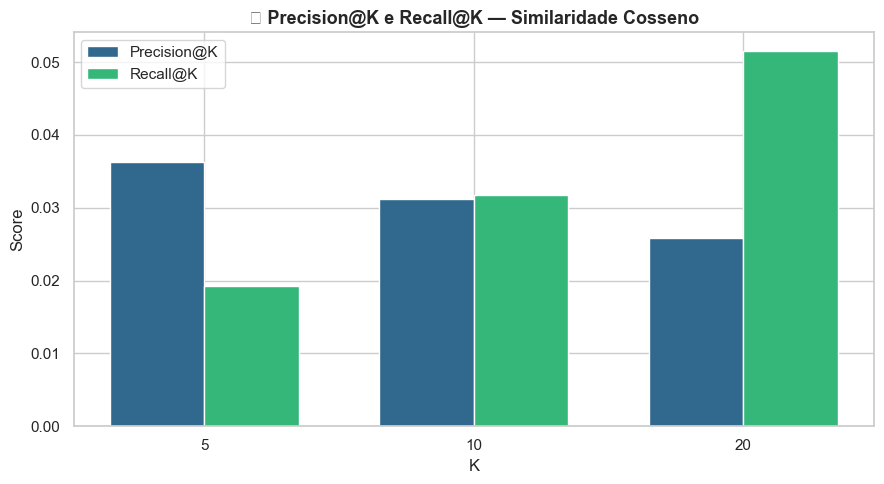

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(metrics))
w = 0.35
ax.bar(x - w/2, metrics["Precision@K"], width=w, label="Precision@K", color=sns.color_palette("viridis",2)[0])
ax.bar(x + w/2, metrics["Recall@K"],    width=w, label="Recall@K",    color=sns.color_palette("viridis",2)[1])
ax.set_xticks(x); ax.set_xticklabels(metrics.index.astype(str))
ax.set_xlabel("K"); ax.set_ylabel("Score")
ax.set_title("🎯 Precision@K e Recall@K — Similaridade Cosseno", fontsize=13, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 💾 9. Exportação

In [17]:
import scipy.sparse as sp

sp.save_npz(PROCESSED_PATH / "item_item_similarity.npz", item_item_similarity.tocsr())

mapping_df = pd.DataFrame({
    "product_id": list(product_to_idx.keys()),
    "matrix_index": list(product_to_idx.values()),
})
mapping_df.to_parquet(PROCESSED_PATH / "product_index_mapping.parquet", index=False)

print("✅ Exportado:")
print(f"   · item_item_similarity.npz       ({item_item_similarity.shape})")
print(f"   · product_index_mapping.parquet  ({mapping_df.shape})")

✅ Exportado:
   · item_item_similarity.npz       ((26686, 26686))
   · product_index_mapping.parquet  ((26686, 2))


## 📌 Conclusão

| Aspecto | Resultado |
|---|---|
| Cobertura | Produtos com ≥ 50 compras (reduz ruído estatístico) |
| Esparsidade da matriz usuário-item | Muito alta (> 99%) — típico em recomendação |
| Similaridade | Captura padrões de **coocorrência agregada**, complementar ao Lift do Market Basket |
| Visualização 2D | Produtos do mesmo departamento tendem a se agrupar no espaço latente |
| Limitação | Não captura semântica do produto, apenas padrão de co-compra — motivo para explorarmos **embeddings aprendidos** no próximo notebook |
